# Churn Prediction: Предсказание оттока платящих пользователей
**Бизнес-задача:** предсказать отток платящих пользователей за 30 дней до события  
для проактивной ретенционной кампании.  
**Модели:** Logistic Regression (baseline) + Random Forest  
**Главная метрика:** ROC-AUC + Precision в топ-20% (Campaign Efficiency)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, precision_score)
from sklearn.pipeline import Pipeline

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Генерация данных
Синтетические поведенческие признаки 10 000 пользователей за наблюдательный период 90 дней

In [2]:
N = 10_000
TRUE_CHURN_RATE = 0.18

df = pd.DataFrame({
    'user_id': range(1, N + 1),
    # демографические
    'account_age_days':   np.random.randint(30, 1800, N),
    'plan_type':          np.random.choice(['free_trial', 'basic', 'pro', 'enterprise'],
                                            N, p=[0.15, 0.40, 0.35, 0.10]),
    'country_tier':       np.random.choice([1, 2, 3], N, p=[0.50, 0.35, 0.15]),
    # активность за последние 30 дней
    'logins_30d':         np.random.negative_binomial(5, 0.5, N),
    'sessions_30d':       np.random.negative_binomial(8, 0.45, N),
    'features_used_30d':  np.random.randint(0, 15, N),
    'support_tickets_30d': np.random.poisson(0.3, N),
    #тренд: последние 30 vs предыдущие 30 дней (отрицательный = снижение активности)
    'activity_trend':     np.random.normal(0, 1, N),
    # платёжные
    'payments_12m':       np.random.poisson(10, N),
    'avg_payment_amount': np.round(np.random.lognormal(6.5, 0.5, N), 2),
    'days_since_last_payment': np.random.randint(1, 45, N),
    'payment_failures_3m': np.random.poisson(0.2, N),
    # NPS
    'nps_score':          np.random.randint(0, 11, N),
    'last_survey_days':   np.random.randint(0, 180, N),
})

# генерация churn с реалистичными зависимостями
log_odds = (
    -2.5
    - 0.003 * df['logins_30d']
    - 0.8   * df['activity_trend']
    + 0.15  * df['support_tickets_30d']
    + 0.04  * df['days_since_last_payment']
    + 0.3   * df['payment_failures_3m']
    - 0.08  * df['nps_score']
    + np.where(df['plan_type'] == 'free_trial', 1.2, 0)
    + np.where(df['plan_type'] == 'enterprise', -1.5, 0)
    + np.random.normal(0, 0.5, N)
)
prob_churn = 1 / (1 + np.exp(-log_odds))
df['churned_30d'] = (np.random.uniform(0, 1, N) < prob_churn).astype(int)

print(f"Датасет: {len(df)} пользователей")
print(f"Churn rate: {df['churned_30d'].mean():.2%}")
print(f"Churned: {df['churned_30d'].sum()} | Active: {(1-df['churned_30d']).sum()}")
df.head()

Датасет: 10000 пользователей
Churn rate: 18.21%
Churned: 1821 | Active: 8179


,user_id,account_age_days,plan_type,country_tier,logins_30d,sessions_30d,features_used_30d,support_tickets_30d,activity_trend,payments_12m,avg_payment_amount,days_since_last_payment,payment_failures_3m,nps_score,last_survey_days,churned_30d
0,1,1156,basic,2,4,7,7,0,1.160699,6,575.01,16,0,2,115,0
1,2,1489,pro,1,7,7,1,0,0.152576,13,705.01,26,3,3,138,0
2,3,890,basic,3,0,13,14,0,-0.926478,17,715.31,29,0,6,102,1
3,4,1324,free_trial,2,8,8,7,0,-0.461200,11,820.64,4,0,3,85,0
4,5,1160,pro,1,2,20,4,0,-0.700187,14,442.67,42,0,1,50,1


## 2. EDA — распределения ключевых признаков

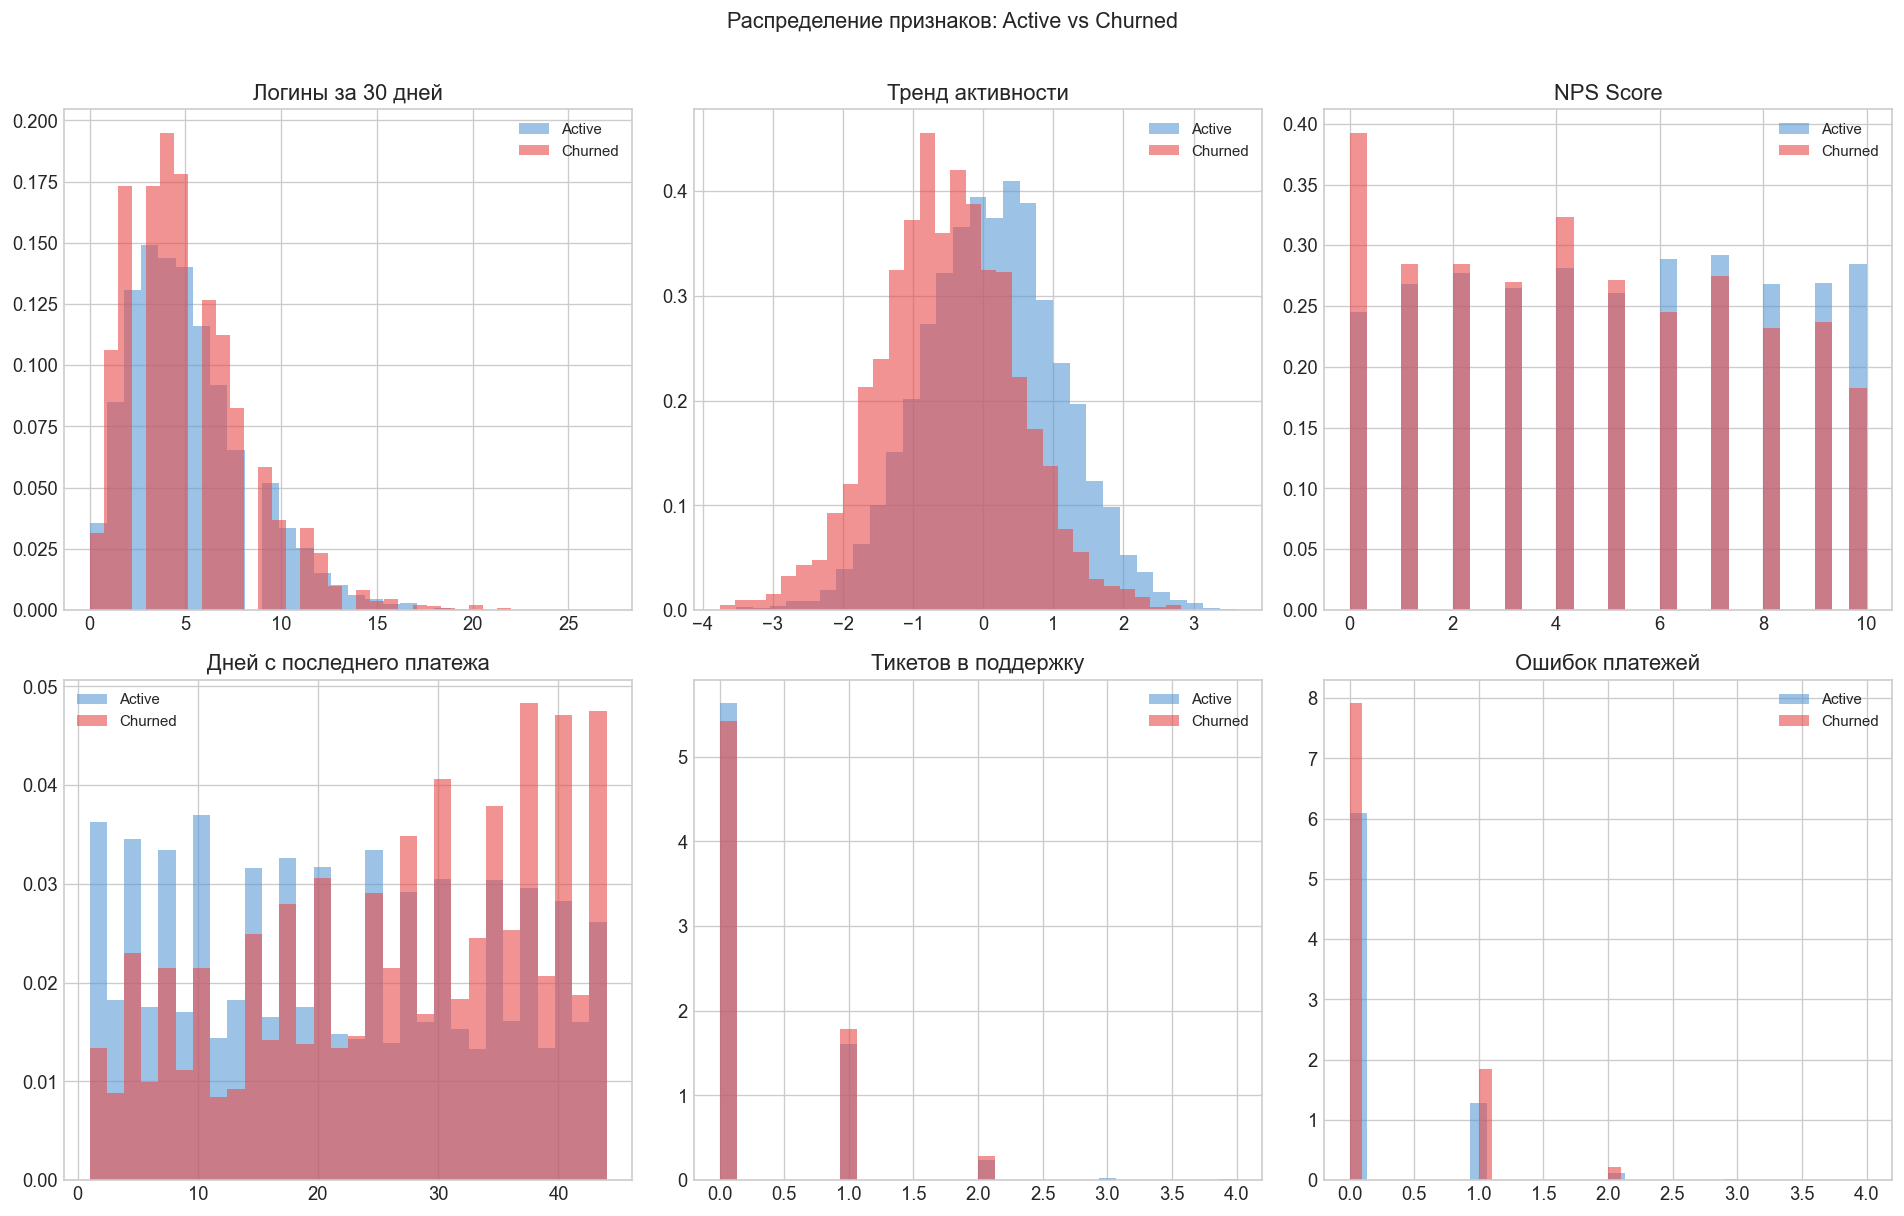

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = [
    ('logins_30d',              'Логины за 30 дней'),
    ('activity_trend',          'Тренд активности'),
    ('nps_score',               'NPS Score'),
    ('days_since_last_payment', 'Дней с последнего платежа'),
    ('support_tickets_30d',     'Тикетов в поддержку'),
    ('payment_failures_3m',     'Ошибок платежей'),
]

for ax, (feat, title) in zip(axes.flatten(), features_to_plot):
    for churn_val, label, color in [(0, 'Active', '#5a9bd4'), (1, 'Churned', '#e84b4b')]:
        vals = df[df['churned_30d'] == churn_val][feat]
        ax.hist(vals, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Распределение признаков: Active vs Churned', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [4]:
#доп признаки
df['logins_per_session']  = df['logins_30d'] / (df['sessions_30d'] + 1)
df['is_declining']        = (df['activity_trend'] < -0.5).astype(int)
df['high_support_burden'] = (df['support_tickets_30d'] >= 2).astype(int)
df['plan_encoded']        = df['plan_type'].map({'free_trial': 0, 'basic': 1, 'pro': 2, 'enterprise': 3})
df['low_nps']             = (df['nps_score'] <= 6).astype(int)

FEATURES = [
    'account_age_days', 'plan_encoded', 'country_tier',
    'logins_30d', 'sessions_30d', 'features_used_30d',
    'support_tickets_30d', 'activity_trend', 'is_declining',
    'payments_12m', 'avg_payment_amount', 'days_since_last_payment',
    'payment_failures_3m', 'nps_score', 'low_nps',
    'logins_per_session', 'high_support_burden', 'last_survey_days',
]

X = df[FEATURES]
y = df['churned_30d']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train churn rate: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Train: 8000 | Test: 2000
Train churn rate: 18.21% | Test: 18.20%


## 4. Моделирование

In [5]:
# логистическая регрессия
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=500, C=0.5, random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_proba_test = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba_test)

#rabdom forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba_test = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba_test)

print(f"Logistic Regression — ROC-AUC: {lr_auc:.4f}")
print(f"Random Forest       — ROC-AUC: {rf_auc:.4f}")

# кросс-валидация для rf
cv_scores = cross_val_score(rf, X_train, y_train,
                             cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
print(f"RF cross-val AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Logistic Regression — ROC-AUC: 0.7626
Random Forest       — ROC-AUC: 0.7598
RF cross-val AUC: 0.7357 +/- 0.0252


## 5. Оценка качества модели

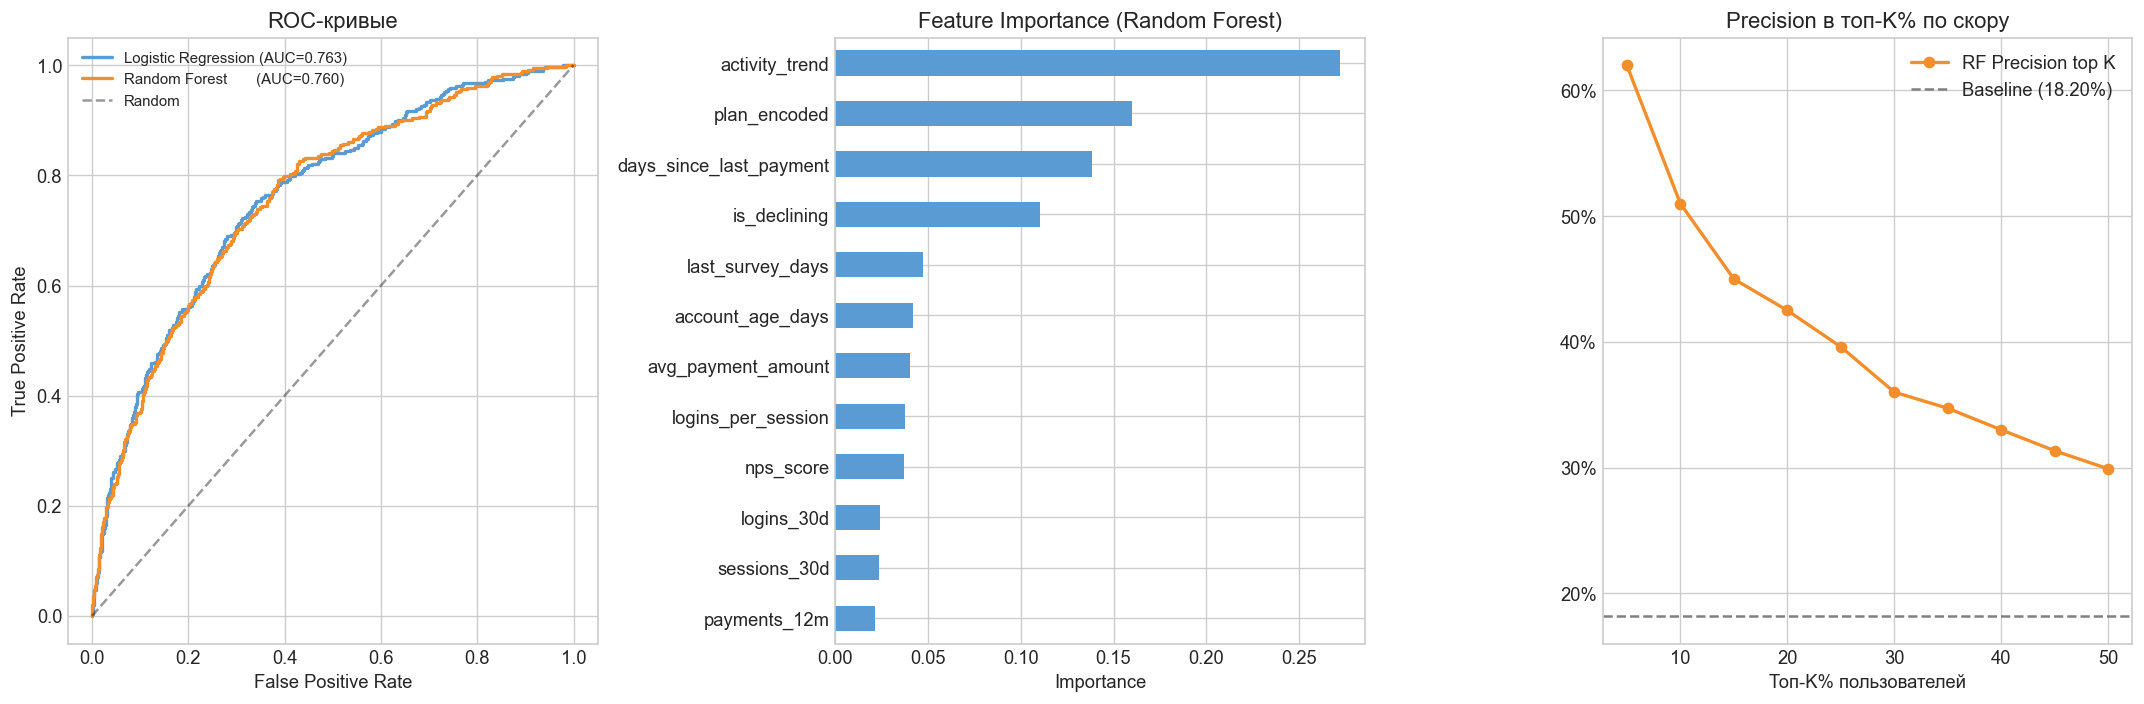


Precision top 20%: 42.50%  (baseline: 18.20%)
Lift top 20%: 2.34x


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ROC кривые
for proba, label, color in [
    (lr_proba_test, f'Logistic Regression (AUC={lr_auc:.3f})', '#5a9bd4'),
    (rf_proba_test, f'Random Forest       (AUC={rf_auc:.3f})', '#f28e2b'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=label, linewidth=2, color=color)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC-кривые')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Feature Importance (RF)
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(12)
fi.plot(kind='barh', ax=axes[1], color='#5a9bd4')
axes[1].set_title('Feature Importance (Random Forest)')
axes[1].set_xlabel('Importance')

# lift кривая: Precision в топ-K%
pct_range = np.arange(5, 55, 5)
precisions = []
test_with_proba = pd.DataFrame({'proba': rf_proba_test, 'actual': y_test.values})
test_with_proba = test_with_proba.sort_values('proba', ascending=False)
for pct in pct_range:
    k = int(len(test_with_proba) * pct / 100)
    top_k = test_with_proba.head(k)
    precisions.append(top_k['actual'].mean())

baseline_precision = y_test.mean()
axes[2].plot(pct_range, precisions, 'o-', color='#f28e2b', linewidth=2, label='RF Precision top K')
axes[2].axhline(baseline_precision, linestyle='--', color='gray', label=f'Baseline ({baseline_precision:.2%})')
axes[2].set_title('Precision в топ-K% по скору')
axes[2].set_xlabel('Топ-K% пользователей')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
axes[2].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()

# Precision@20% — главная бизнес-метрика
k20 = int(len(test_with_proba) * 0.20)
precision_20 = test_with_proba.head(k20)['actual'].mean()
print(f"\nPrecision top 20%: {precision_20:.2%}  (baseline: {baseline_precision:.2%})")
print(f"Lift top 20%: {precision_20/baseline_precision:.2f}x")

## 6. Бизнес-ROI ретенционной кампании

In [ ]:
#параметры
MONTHLY_ACTIVE_PAYING  = 50_000    # всего платящих пользователей
CAMPAIGN_COVERAGE      = 0.20      # охватываем топ-20% по скору
AVG_MONTHLY_REVENUE    = 800       # руб/пользователь
RETENTION_OFFER_COST   = 150       # стоимость оффера (скидка / бонус)
RETENTION_SUCCESS_RATE = 0.35      # 35% из предложенных принимают оффер и остаются
REVENUE_HORIZON_MONTHS = 3         # горизонт планирования

targeted_users       = int(MONTHLY_ACTIVE_PAYING * CAMPAIGN_COVERAGE)
true_churners_caught = int(targeted_users * precision_20)
additional_retained  = int(true_churners_caught * RETENTION_SUCCESS_RATE)

revenue_saved    = additional_retained * AVG_MONTHLY_REVENUE * REVENUE_HORIZON_MONTHS
campaign_cost    = targeted_users * RETENTION_OFFER_COST
roi_net          = revenue_saved - campaign_cost
churn_reduction  = additional_retained / MONTHLY_ACTIVE_PAYING

print("=" * 55)
print("БИЗНЕС-ЭФФЕКТ МОДЕЛИ (в месяц)")
print("=" * 55)
print(f"Охват кампании (топ 20%):     {targeted_users} пользователей")
print(f"Точно угаданных чёрнеров:     {true_churners_caught:,}  ({precision_20:.0%} precision)")
print(f"Удержанных (acceptance 35%):  {additional_retained:,}")
print(f"Выручка (горизонт 3 месяца):  {revenue_saved:,} руб/мес")
print(f"Затраты на кампанию:          {campaign_cost:,} руб/мес")
print(f"Чистый эффект (ROI):          {roi_net:,} руб/мес  ({'прибыль' if roi_net>0 else 'убыток'})")
print(f"Снижение churn rate:          -{churn_reduction:.2%} п.п.")
print(f"Годовой эффект:               {roi_net*12:,} руб/год")
print()
print("ВЫВОД: Модель с Precision top 20% {:.0%} даёт {:.1f}x lift над baseline.".format(
    precision_20, precision_20 / baseline_precision))
print("Рекомендация: внедрить в ретенционную кампанию с ежемесячным скорингом")

БИЗНЕС-ЭФФЕКТ МОДЕЛИ (в месяц)
Охват кампании (топ 20%):     10000 пользователей
Точно угаданных чёрнеров:     4,250  (42% precision)
Удержанных (acceptance 35%):  1,487
Выручка (горизонт 3 месяца):  3,568,800 руб/мес
Затраты на кампанию:          1,500,000 руб/мес
Чистый эффект (ROI):          2,068,800 руб/мес  (прибыль)
Снижение churn rate:          -2.97% п.п.
Годовой эффект:               24,825,600 руб/год

ВЫВОД: Модель с Precision top 20% 42% даёт 2.3x lift над baseline.
Рекомендация: внедрить в ретенционную кампанию с ежемесячным скорингом.
